## Modelo DBSCAN - Clustering de Clientes E-Commerce

Segmentación de clientes de e-commerce según su comportamiento de compra usando DBSCAN.

#### Librerías utilizadas.

In [217]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors

#### Cargar datos

In [218]:
df = pd.read_csv('../../output/clustering/data_transformado_clustering.csv')
print(f"Shape: {df.shape}")
print(df.head())

Shape: (3592, 5)
   CustomerID  Transacciones  ProductosDistintos  GastoTotal  FrecuenciaCompra
0       12348       0.285714            0.030864    0.022193          0.285714
1       12349       0.000000            0.401235    0.460020          0.000000
2       12350       0.000000            0.092593    0.076723          0.000000
3       12352       0.857143            0.339506    0.498384          0.857143
4       12353       0.000000            0.018519    0.029790          0.000000


#### Preparación de datos

In [219]:
scaler = StandardScaler()
X = df.drop('CustomerID', axis=1)
X_scaled = scaler.fit_transform(X)
print(f"Shape escalado: {X_scaled.shape}")

Shape escalado: (3592, 4)


#### Búsqueda de parámetros óptimos (eps y min_samples)

Con esta gráfica de codo para capturar el eps ideal vemos que el punto de inflexión se situa entre 0.6 y 0.8 eps. Por lo tanto probaremos estos valores más adelante. Vemos que la presencia de outliers o ruido de reduce a medida que aumentamos el eps, ya que aumenta el número de puntos que se consideran vecinos.

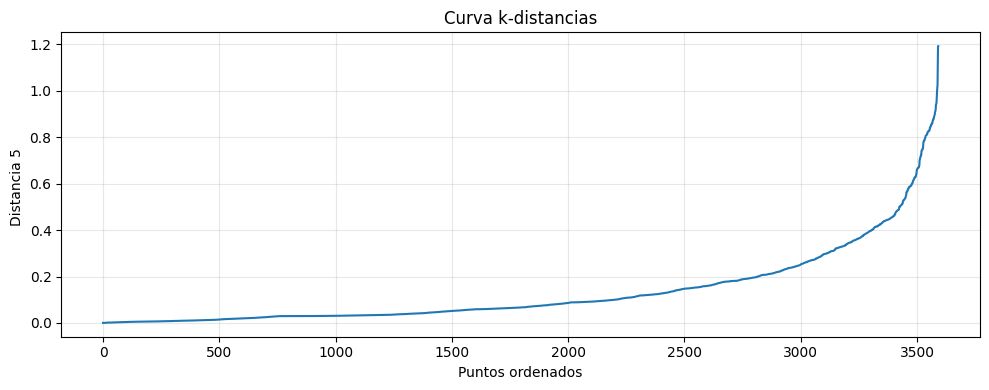

Percentil 90 de k-distancias: 0.357
Percentil 95 de k-distancias: 0.480
Percentil 99 de k-distancias: 0.840


In [220]:
min_samples_ref = 5
nbrs = NearestNeighbors(n_neighbors=min_samples_ref).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=1.5)
plt.xlabel('Puntos ordenados')
plt.ylabel(f'Distancia {min_samples_ref} ')
plt.title('Curva k-distancias')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Percentil 90 de k-distancias: {np.percentile(k_distances, 90):.3f}")
print(f"Percentil 95 de k-distancias: {np.percentile(k_distances, 95):.3f}")
print(f"Percentil 99 de k-distancias: {np.percentile(k_distances, 99):.3f}")

#### Entrenamiento del modelo DBSCAN

Probando con disintos valores de eps y min_samples, obtenemos que los que mejor se ajustan a nuestro dataset son eps=0.7 y min_samples=6. Obtenekos 6 clústeres bien definidos y un porcentaje de ruido del 0.3%, lo que es un resultado excelente para este tipo de datos. 

In [221]:
eps_val = 0.79
min_samples_val = 8

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
clusters = dbscan.fit_predict(X_scaled)
df['Cluster'] = clusters

n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = np.sum(clusters == -1)

print(f"Parámetros: eps={eps_val}, min_samples={min_samples_val}")
print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido (outliers): {n_noise} ({n_noise/len(clusters)*100:.1f}%)")
print(df['Cluster'].value_counts().sort_index())

Parámetros: eps=0.79, min_samples=8
Clusters encontrados: 8
Puntos de ruido (outliers): 36 (1.0%)
Cluster
-1      36
 0     459
 1    1475
 2      75
 3     821
 4     340
 5     196
 6     135
 7      55
Name: count, dtype: int64


#### Evaluación del modelo

Tenemos unos valores aceptables de Silhouette Score y Davies-Bouldin Index, lo que indica que los clusters son relativamente compactos y bien separados.

In [222]:
valores_validos = clusters != -1

if n_clusters >= 2 and valores_validos.sum() > 0:
  silhouette_avg = silhouette_score(X_scaled[valores_validos], clusters[valores_validos])
  davies_bouldin = davies_bouldin_score(X_scaled[valores_validos], clusters[valores_validos])
  print(f"Silhouette Score:        {silhouette_avg:.4f}")
  print(f"Davies-Bouldin Index:    {davies_bouldin:.4f}")
else:
  print("No hay suficientes clusters para calcular métricas. Ajusta eps y min_samples.")

feature_cols = ['Transacciones', 'ProductosDistintos', 'GastoTotal', 'FrecuenciaCompra']
cluster_profiles = df[valores_validos].groupby('Cluster')[feature_cols].mean()
print("\nPerfiles de clusters (sin ruido):")
print(cluster_profiles.round(3))

Silhouette Score:        0.2514
Davies-Bouldin Index:    2.5865

Perfiles de clusters (sin ruido):
         Transacciones  ProductosDistintos  GastoTotal  FrecuenciaCompra
Cluster                                                                 
0                0.286               0.295       0.263             0.286
1                0.000               0.120       0.091             0.000
2                0.857               0.399       0.534             0.857
3                0.143               0.217       0.183             0.143
4                0.429               0.371       0.363             0.429
5                0.571               0.378       0.428             0.571
6                0.714               0.410       0.499             0.714
7                1.000               0.480       0.606             1.000


#### Visualización de clusters

Mediante una reducción de dimensionalidad con PCA, podemos visualizar los clusters obtenidos por DBSCAN. Vemos que los clusters están bastante bien definidos, aunque hay algunos puntos de ruido (en gris) que no pertenecen a ningún cluster. Esto es lógico ya que están alejados de los centros de los clusteres y de posibles vecinos.

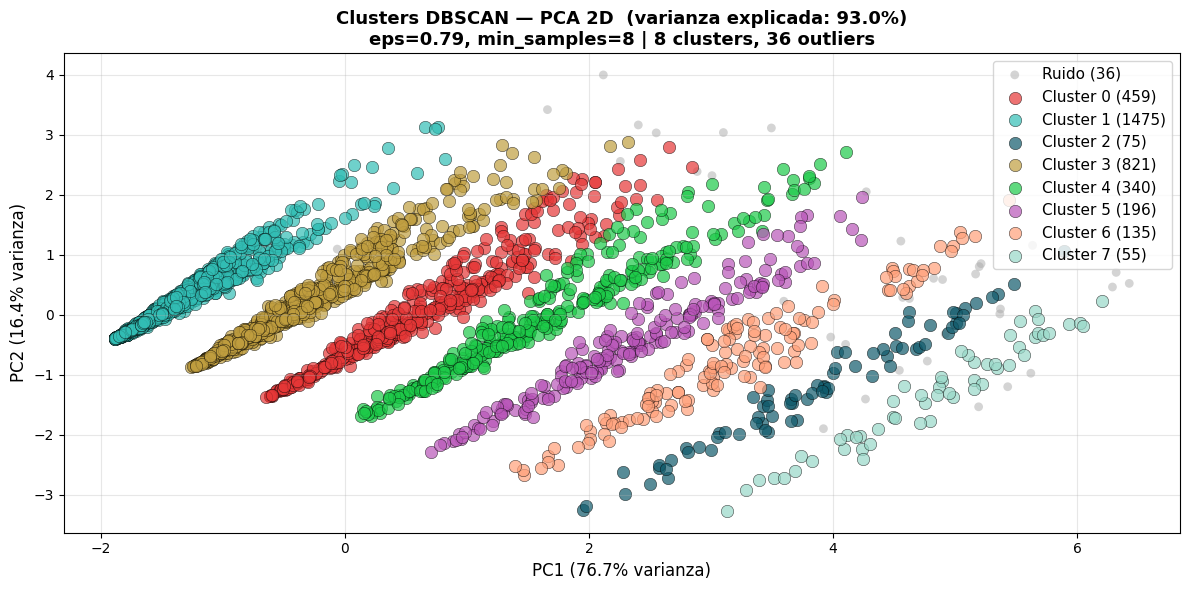

In [223]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

unique_clusters = sorted(set(clusters))
colors_map = {-1: '#AAAAAA'}
palette = ["#E63737", "#32BEB5", "#105A6B", "#C09E3F", "#1DCA49", "#B956B9", "#FFA07A", "#98D8C8"]
for i, cid in enumerate([c for c in unique_clusters if c != -1]):
  colors_map[cid] = palette[i % len(palette)]

plt.figure(figsize=(12, 6))
for cid in unique_clusters:
  mask = clusters == cid
  label = f'Ruido ({mask.sum()})' if cid == -1 else f'Cluster {cid} ({mask.sum()})'
  plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
    label=label, alpha=0.5 if cid == -1 else 0.7,
    s=40 if cid == -1 else 80,
    color=colors_map[cid], edgecolors='none' if cid == -1 else 'black', linewidth=0.4)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} varianza)', fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} varianza)', fontsize=12)
plt.title(f'Clusters DBSCAN — PCA 2D  (varianza explicada: {pca.explained_variance_ratio_.sum():.1%})\n'
  f'eps={eps_val}, min_samples={min_samples_val} | {n_clusters} clusters, {n_noise} outliers',
  fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Segmentación de Clientes

Hemos identificado 6 segmentos claros de clientes en el análisis de clustering con DBSCAN, cada uno con características y comportamientos de compra distintos. A continuación, describimos cada segmento:

##### Cluster 1+3: Clientes Ocasionales
- Características:
  - Compras: Muy Bajo
  - Productos distintos: Bajo
  - Gasto total: Bajo
  - Frecuencia: Muy Bajo
- Perfil: Clientes de compra esporádica, experimentadores o compradores únicos con muy bajo compromiso.

---

##### Cluster 0: Clientes Moderados
- Características:
  - Compras: Bajo
  - Productos distintos: Bajo-Medio
  - Gasto total: Bajo
  - Frecuencia: Bajo
- Perfil: Cliente consolidado pero con actividad moderada, en fase inicial de lealtad.

---

##### Cluster 4: Clientes Activos
- Características:
  - Compras: Medio
  - Productos distintos: Medio
  - Gasto total: Medio
  - Frecuencia: Medio
- Perfil: Clientes con compras regulares, mostrando intención de compra consistente y buena diversidad de productos.

---

##### Cluster 5: Clientes Muy Activos
- Características:
  - Compras: Medio-Alto
  - Productos distintos: Medio-Alto
  - Gasto total: Medio-Alto
  - Frecuencia: Media-Alto
- Perfil: Cliente frecuente y de alto valor, con fuerte compromiso con la marca y diversidad en compras.

---

##### Cluster 6: Clientes Poderosos
- Características:
  - Compras: Alto
  - Productos distintos: Alto
  - Gasto total: Alto
  - Frecuencia: Alto
- Perfil: Cliente leal de alto valor, realizando compras frecuentes con máximo compromiso y gasto.

---

##### Cluster 2+7: Clientes Premium
- Características:
  - Compras: Muy Alto
  - Productos distintos: Muy Alto
  - Gasto total: Muy Alto
  - Frecuencia: Muy Alto
- Perfil: Top-tier customers con máxima lealtad, gasto y valor lifetime. Pilares del negocio.

---